In [2]:
import pandas as pd

students = pd.read_csv('/content/StudentsPerformance.csv')
students.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/StudentsPerformance.csv'

In [3]:
import os
print(os.listdir('/content'))

['.config', 'archive (2).zip', 'sample_data']


In [4]:
import zipfile

with zipfile.ZipFile('/content/archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/student_data')

print("Extracted Successfully")

Extracted Successfully


In [5]:
import os
print(os.listdir('/content/student_data')
)

['StudentsPerformance.csv']


In [6]:
import pandas as pd

students = pd.read_csv('/content/student_data/StudentsPerformance.csv')

students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
print("Shape of Dataset:", students.shape)

print("\nColumn Names:")
print(students.columns)

print("\nData Types:")
print(students.dtypes)

print("\nMissing Values:")
print(students.isnull().sum())

Shape of Dataset: (1000, 8)

Column Names:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

Data Types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [8]:
print("Shape of Dataset:", students.shape)

print("\nColumn Names:")
print(students.columns)

print("\nData Types:")
print(students.dtypes)

print("\nMissing Values:")
print(students.isnull().sum())

print("\nDuplicate Rows:")
print(students.duplicated().sum())

Shape of Dataset: (1000, 8)

Column Names:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

Data Types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate Rows:
0


# Dataset Summary

1. The dataset contains 1000 student records and 8 attributes related to academic performance and demographic factors.
2. It includes information such as gender, parental education level, lunch type, test preparation status, and scores in math, reading, and writing.
3. The dataset has no missing values, making it suitable for analysis without additional data cleaning.
4. No duplicate records were found, indicating good data quality and consistency.
5. The dataset can be used to identify factors affecting student performance and to detect students who may be academically at risk.


In [9]:
students['total_score'] = (
    students['math score'] +
    students['reading score'] +
    students['writing score']
)

students[['math score','reading score','writing score','total_score']].head()

,math score,reading score,writing score,total_score
0,72,72,74,218
1,69,90,88,247
2,90,95,93,278
3,47,57,44,148
4,76,78,75,229


In [10]:
parent_edu = students.groupby('parental level of education')[
    ['math score', 'reading score', 'writing score']
].mean().round(2)

print(parent_edu.sort_values('math score', ascending=False))

                             math score  reading score  writing score
parental level of education                                          
master's degree                   69.75          75.37          75.68
bachelor's degree                 69.39          73.00          73.38
associate's degree                67.88          70.93          69.90
some college                      67.13          69.46          68.84
some high school                  63.50          66.94          64.89
high school                       62.14          64.70          62.45


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
parent_edu = students.groupby('parental level of education')[
    ['math score', 'reading score', 'writing score']
].mean().round(2)

print(parent_edu.sort_values('math score', ascending=False))

                             math score  reading score  writing score
parental level of education                                          
master's degree                   69.75          75.37          75.68
bachelor's degree                 69.39          73.00          73.38
associate's degree                67.88          70.93          69.90
some college                      67.13          69.46          68.84
some high school                  63.50          66.94          64.89
high school                       62.14          64.70          62.45


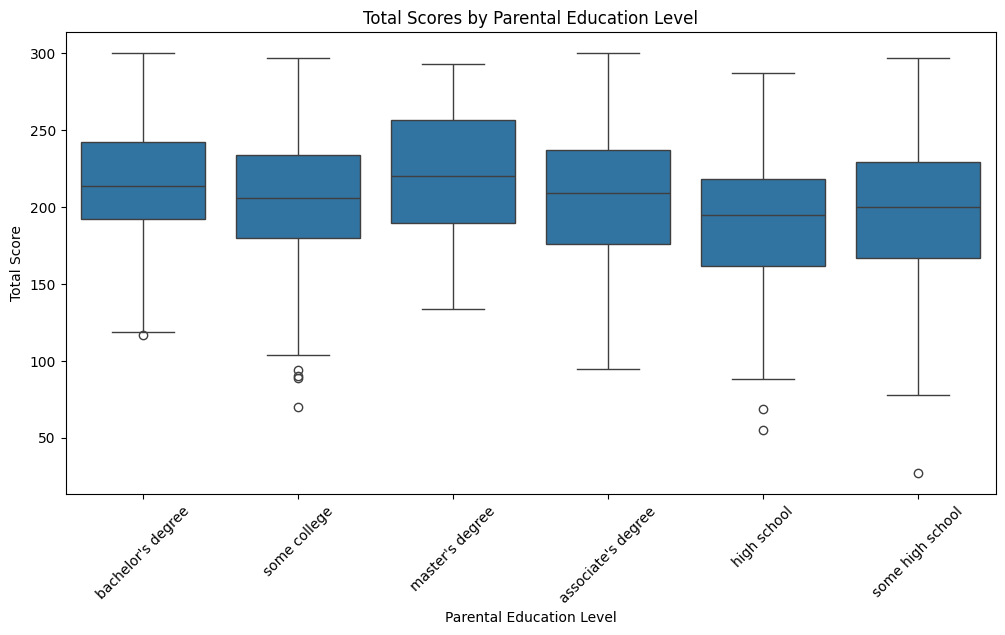

In [16]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='parental level of education',
    y='total_score',
    data=students
)

plt.title('Total Scores by Parental Education Level')
plt.xlabel('Parental Education Level')
plt.ylabel('Total Score')
plt.xticks(rotation=45)
plt.show()

In [17]:
test_prep = students.groupby('test preparation course')[
    ['math score', 'reading score', 'writing score']
].mean().round(2)

print(test_prep)

                         math score  reading score  writing score
test preparation course                                          
completed                     69.70          73.89          74.42
none                          64.08          66.53          64.50


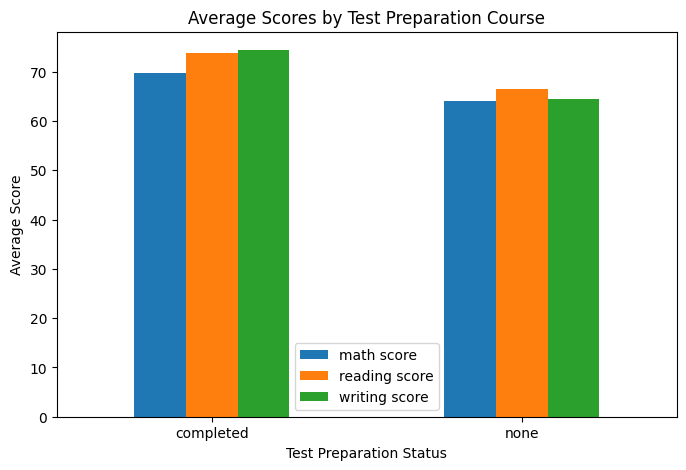

In [18]:
test_prep.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Scores by Test Preparation Course')
plt.xlabel('Test Preparation Status')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [19]:
correlation = students[
    ['math score', 'reading score', 'writing score']
].corr()

print(correlation)

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


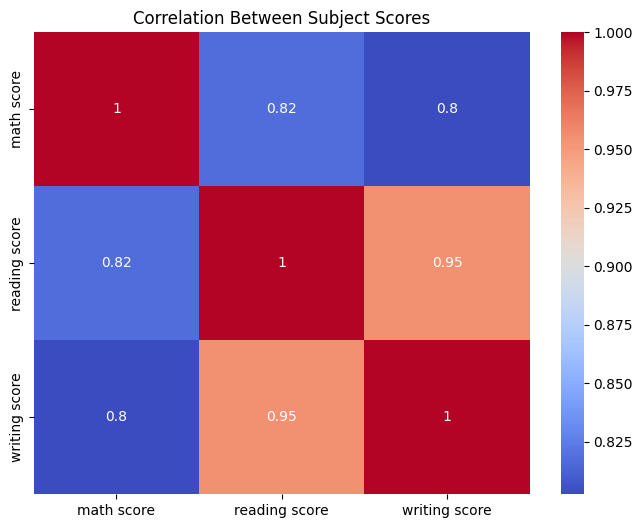

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Subject Scores')
plt.show()

In [21]:
gender_scores = students.groupby('gender')[
    ['math score', 'reading score', 'writing score']
].mean().round(2)

print(gender_scores)

        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31


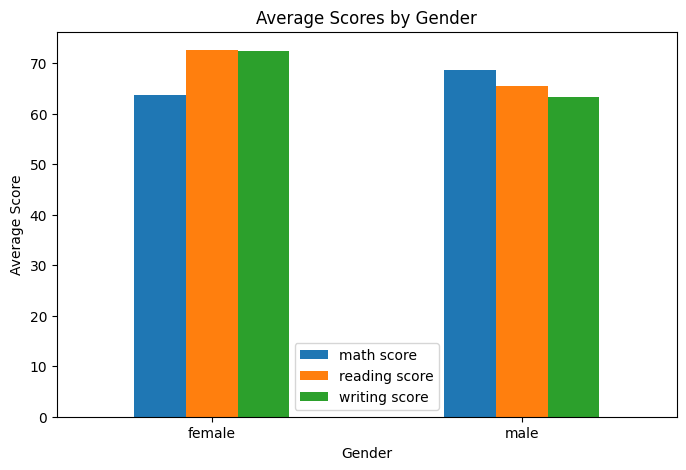

In [22]:
gender_scores.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Scores by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [23]:
print(students['total_score'].describe())

count    1000.000000
mean      203.312000
std        42.771978
min        27.000000
25%       175.000000
50%       205.000000
75%       233.000000
max       300.000000
Name: total_score, dtype: float64


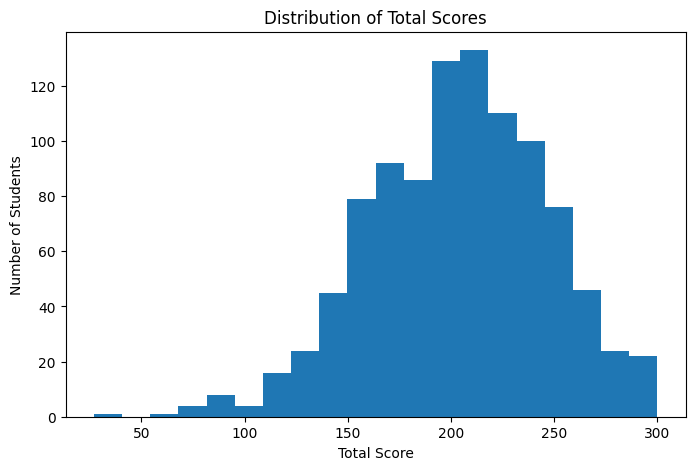

In [24]:
plt.figure(figsize=(8,5))

plt.hist(
    students['total_score'],
    bins=20
)

plt.title('Distribution of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Number of Students')
plt.show()

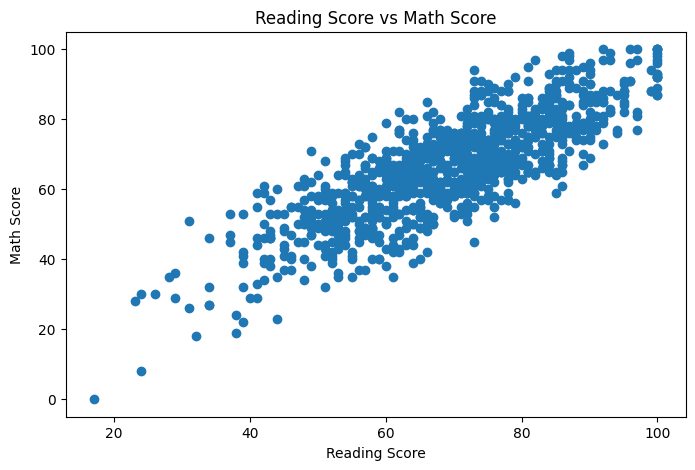

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(
    students['reading score'],
    students['math score']
)

plt.title('Reading Score vs Math Score')
plt.xlabel('Reading Score')
plt.ylabel('Math Score')
plt.show()

In [26]:
at_risk = students[
    (students['math score'] < 50) |
    (students['reading score'] < 50) |
    (students['writing score'] < 50)
]

print("Number of At-Risk Students:", len(at_risk))

Number of At-Risk Students: 188


In [27]:
students['at_risk'] = (
    (students['math score'] < 50) |
    (students['reading score'] < 50) |
    (students['writing score'] < 50)
)

risk_by_gender = (
    students.groupby('gender')['at_risk']
    .mean() * 100
).round(2)

print(risk_by_gender)

gender
female    17.18
male      20.54
Name: at_risk, dtype: float64


In [28]:
risk_by_prep = (
    students.groupby('test preparation course')['at_risk']
    .mean() * 100
).round(2)

print(risk_by_prep)

test preparation course
completed    10.06
none         23.68
Name: at_risk, dtype: float64


# At-Risk Student Segmentation

An at-risk student is defined as a student scoring below 50 in at least one subject (Math, Reading, or Writing).

Total At-Risk Students: 188

Key Findings:

1. 188 out of 1000 students were identified as at-risk.
2. Male students had a higher at-risk percentage (20.54%) compared to female students (17.18%).
3. Students who did not complete the test preparation course had a significantly higher at-risk percentage (23.68%).
4. Students who completed the test preparation course had a much lower at-risk percentage (10.06%).
5. Test preparation appears to be one of the most important factors influencing student success.

Reason:
Students without academic preparation may struggle with exam techniques, time management, and subject understanding, leading to lower scores.


# Principal's Report

## Executive Summary

This analysis examined student performance data to identify factors influencing academic success and to detect students at risk of poor performance. The results show that parental education level, gender differences, and participation in test preparation courses all affect student outcomes. A total of 188 students were identified as academically at risk and may require additional support.

## Key Findings

1. Students whose parents have higher education levels generally achieved better academic results.
2. Students who completed the test preparation course scored significantly higher in all subjects.
3. Reading and writing scores showed a very strong positive correlation (0.955).
4. Male students performed better in mathematics, while female students performed better in reading and writing.
5. A total of 188 students were classified as at-risk because they scored below 50 in at least one subject.

## Recommendations

1. Expand access to test preparation programs for all students, especially those with low academic performance.
2. Provide targeted academic support and mentoring for at-risk students before examinations.
3. Organize parental engagement programs to encourage stronger educational support at home.

## Conclusion

The analysis demonstrates that preparation, parental involvement, and targeted academic support play important roles in student success. Implementing the recommended strategies can improve academic outcomes and reduce the number of at-risk students in future academic years.


# Most Impactful Recommendation

The most impactful recommendation is expanding access to test preparation programs. The analysis showed that students who completed the test preparation course scored significantly higher and had a much lower at-risk percentage than those who did not participate. Providing structured preparation opportunities can help students improve confidence, exam readiness, and overall academic performance.
